<a href="https://colab.research.google.com/github/n-manato/audio-data-modeling/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Speech Emotion Recognition using the RAVDESS Dataset

## Objective
The goal of this notebook is to explore how speech audio can be used to classify emotions.
Using the RAVDESS dataset, I process speech recordings, visualize the audio signals, extract **Mel Spectrogram** features, and train simple machine learning models.
This notebook demonstrates the basic workflow of audio processing and emotion classification in Google Colab.


# Import Libraries
In this section, I import the Python libraries needed for audio processing, data handling, visualization, and machine learning.

In [ ]:
# Import Libraries

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load Dataset
In this section, I load the speech audio files from the RAVDESS dataset.
I organize the files and prepare them for audio analysis and emotion classification.

In [ ]:
# RAVDESS dataset folder path

dataset_path = "./Audio_Speech_Actors_01-24"

# Emotion labels used in RAVDESS
emotion_map = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

# Collect all .wav files
audio_files = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print("Number of audio files:", len(audio_files))
print("First sample file:", os.path.basename(audio_files[0]))

# Select emotions to compare
selected_emotions = {"01", "03", "04", "05"}  # neutral, happy, sad, angry

# Store one sample file for each selected emotion
sample_by_emotion = {}

for file in audio_files:
    filename = os.path.basename(file)
    parts = filename.split("-")
    emotion_code = parts[2]

    if emotion_code in selected_emotions and emotion_code not in sample_by_emotion:
        sample_by_emotion[emotion_code] = file

# Order of emotions in the plots
emotion_order = ["01", "03", "04", "05"]

print("Selected sample files:")
for code in emotion_order:
    print(code, emotion_map[code], "->", os.path.basename(sample_by_emotion[code]))

Number of audio files: 1440
First sample file: 03-01-01-01-01-01-01.wav
Selected sample files:
01 neutral -> 03-01-01-01-01-01-01.wav
03 happy -> 03-01-03-01-01-01-01.wav
04 sad -> 03-01-04-01-01-01-01.wav
05 angry -> 03-01-05-01-01-01-01.wav


# Explore Audio
In this section, I visualize sample audio files using waveforms and spectrograms.
This helps me understand the speech signals before building a model.

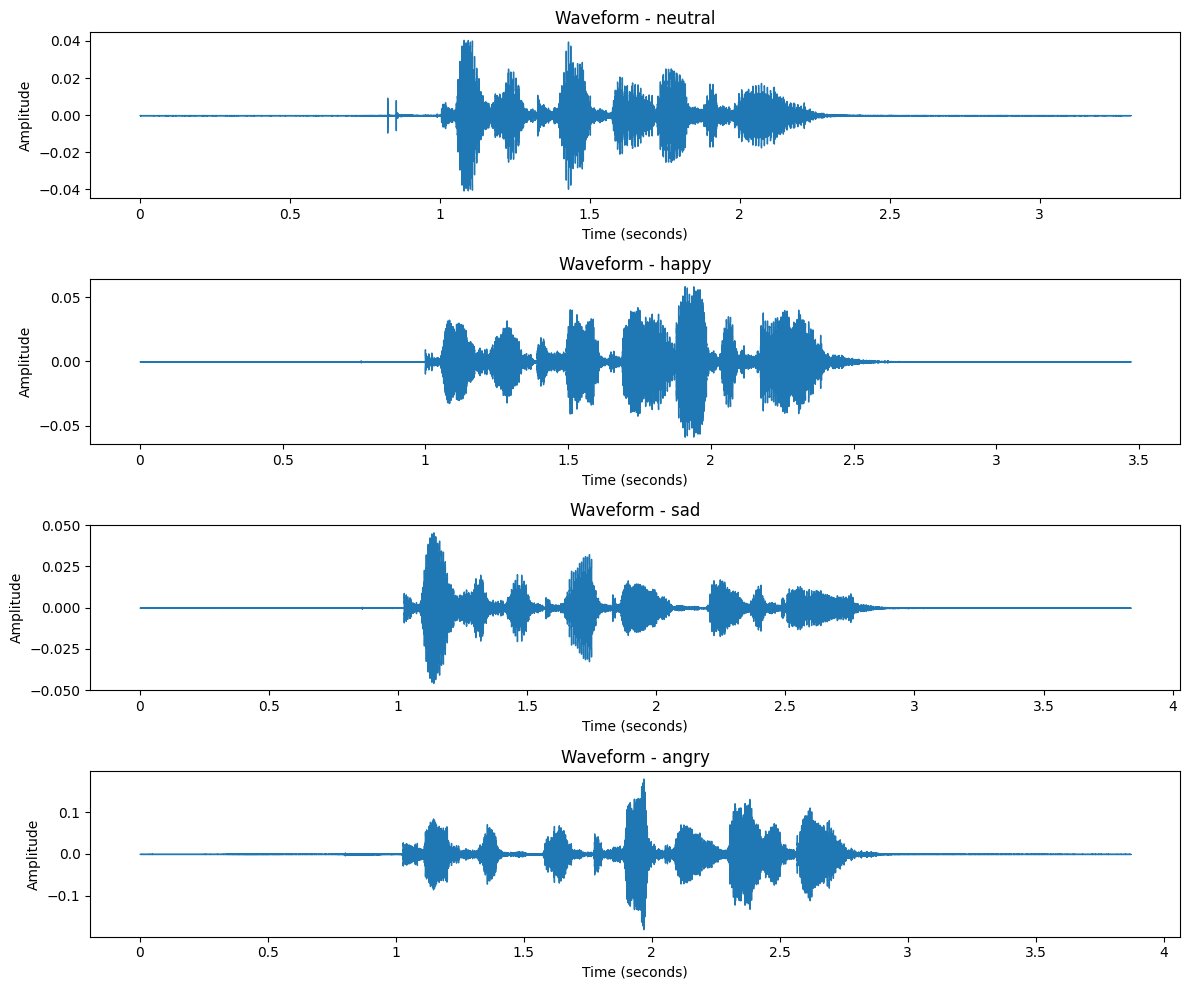

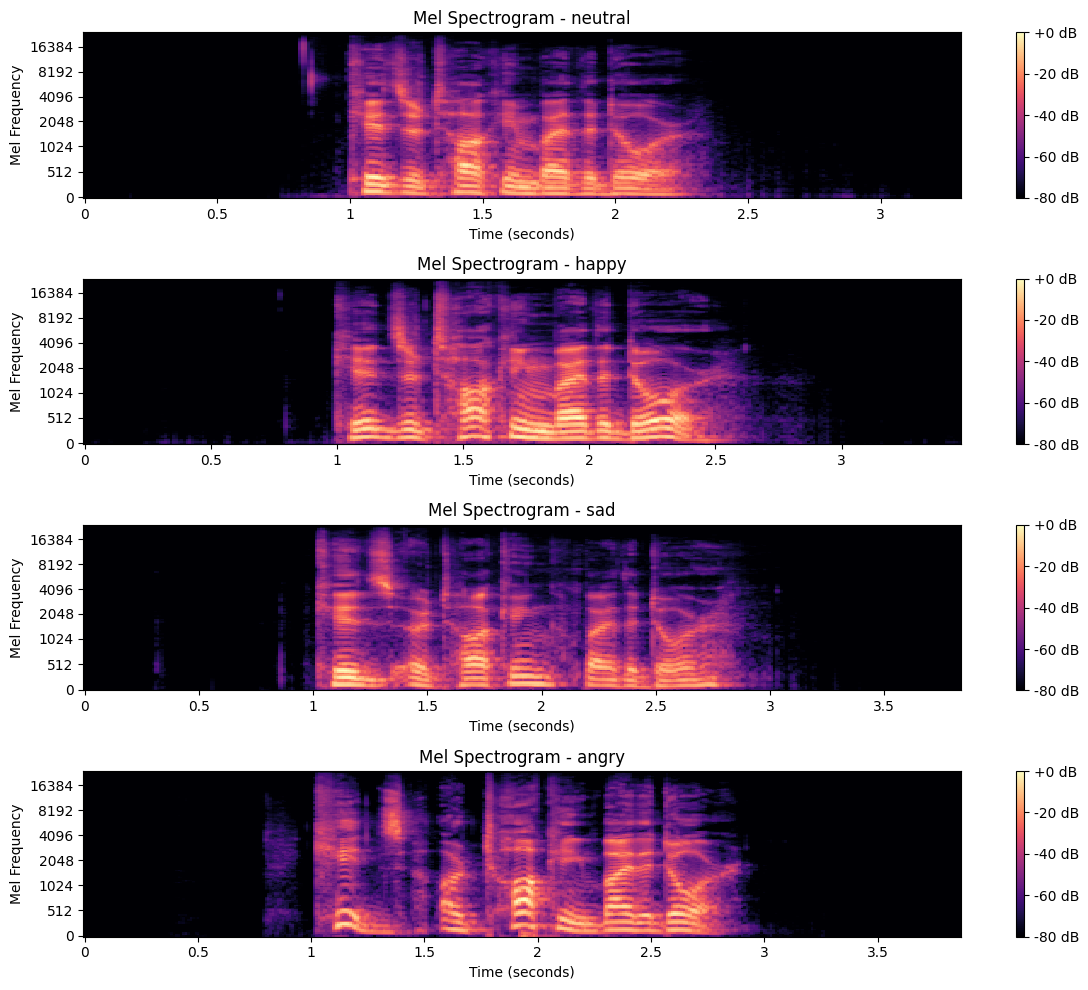

In [ ]:
# Explore Audio

plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    plt.subplot(len(emotion_order), 1, i)
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 10))

for i, emotion_code in enumerate(emotion_order, 1):
    sample_file = sample_by_emotion[emotion_code]
    y, sr = librosa.load(sample_file, sr=None)

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    plt.subplot(len(emotion_order), 1, i)
    img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
    plt.title(f"Mel Spectrogram - {emotion_map[emotion_code]}")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Mel Frequency")
    plt.colorbar(img, format="%+2.0f dB")

plt.tight_layout()
plt.show()


In the waveform, the signal is close to zero at the beginning and end, which suggests silence or very low background sound.
The main speech activity occurs in the middle of the recording, where the amplitude becomes much larger.

In the **Mel Spectrogram**, stronger energy appears mainly during the same middle section.
Brighter regions show where the signal has higher energy, while darker regions show weaker energy.
Because the vertical axis uses the mel scale, it represents frequency in a way that is closer to how humans hear sound.
These plots show that the recording contains useful time-frequency patterns that can be used for feature extraction and emotion classification.


# Feature Extraction
In this section, I extract **Mel Spectrogram** features from the audio files.
These features represent time-frequency information from the speech signal and will be used for model training.


Feature matrix shape: (672, 128)
Label shape: (672,)
Sample labels: ['neutral' 'neutral' 'neutral' 'neutral' 'happy' 'happy' 'happy' 'happy'
 'happy' 'happy']
First feature vector: [-52.144424   -52.11628    -53.76868    -54.32599    -55.668358
 -55.256466   -55.227047   -55.75535    -57.618908   -60.053352
 -61.04855    -62.06827    -63.783833   -64.1027     -63.764168
 -64.071205   -63.90419    -62.80196    -63.15739    -62.968685
 -62.90957    -62.948753   -63.209263   -64.13909    -65.26058
 -65.234344   -65.84819    -65.56186    -64.213486   -64.041565
 -65.651276   -67.17286    -66.924095   -65.99642    -65.82543
 -67.001915   -70.14658    -70.16559    -70.75327    -71.87359
 -72.2908     -71.58925    -69.32213    -69.3313     -70.4201
 -71.40061    -72.24405    -73.59308    -73.38189    -72.85452
 -72.022934   -71.69902    -72.32524    -71.87829    -72.14544
 -72.64544    -73.57233    -74.20315    -75.75101    -76.94558
 -77.85693    -78.72606    -79.14477    -79.7996      24.66

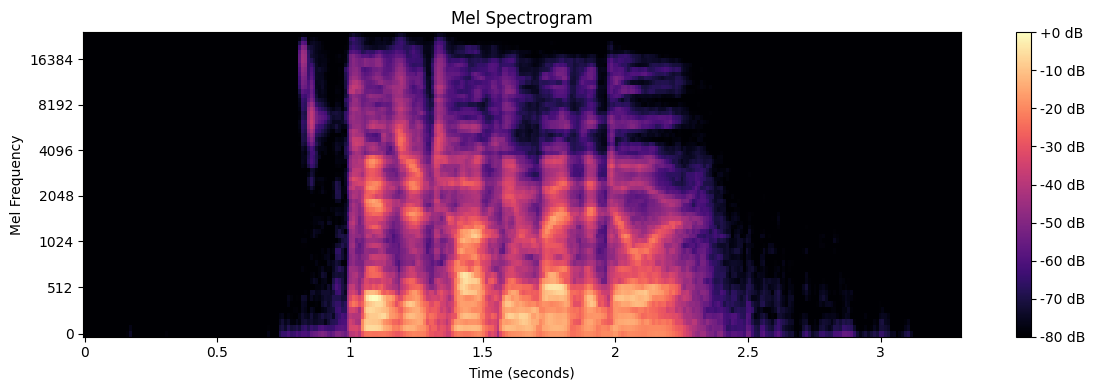

In [ ]:
# Feature Extraction

selected_emotions = {"01", "03", "04", "05"}

X = []
y_labels = []

for file_path in audio_files:
    file_name = os.path.basename(file_path)
    emotion_code = file_name.split("-")[2]

    if emotion_code in selected_emotions:
        signal, sr = librosa.load(file_path, sr=None)

        # Extract Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=signal,
            sr=sr,
            n_mels=64,
            n_fft=2048,
            hop_length=512
        )
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Create a fixed-length feature vector using statistics across time
        mel_mean = np.mean(mel_spec_db, axis=1)
        mel_std = np.std(mel_spec_db, axis=1)
        feature_vector = np.concatenate([mel_mean, mel_std])

        X.append(feature_vector)
        y_labels.append(emotion_map[emotion_code])

X = np.array(X)
y_labels = np.array(y_labels)

print("Feature matrix shape:", X.shape)
print("Label shape:", y_labels.shape)
print("Sample labels:", y_labels[:10])
print("First feature vector:", X[0])

sample_file = audio_files[0]

y, sr = librosa.load(sample_file, sr=None)

mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=64,
    n_fft=2048,
    hop_length=512
)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

print("Mel Spectrogram shape:", mel_spec_db.shape)

plt.figure(figsize=(12, 4))
librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency")
plt.tight_layout()
plt.show()


In this step, I extract features based on the **Mel Spectrogram** instead of pitch contour (F0).

A Mel Spectrogram shows how the energy of the audio signal changes over time across different frequency bands.
Because each audio file may have a different number of time frames, I convert it into a fixed-length feature vector by calculating summary statistics for each mel band.

The extracted Mel Spectrogram-based features are:

- mean value of each mel band across time
- standard deviation of each mel band across time

These features are useful because they summarize both the overall energy distribution and the variation of the speech signal in the time-frequency domain.
This is important for emotion recognition, since emotional speech often differs in intensity, resonance, and spectral shape.


# Model Training
In this section, I split the dataset into training and testing sets and train simple machine learning models.
I use the extracted **Mel Spectrogram** features to classify emotions.
The goal is to see whether time-frequency information from speech can help identify emotional expression.


In [ ]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

# Define 3 models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),

    "SVM": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=1.0, gamma="scale")
    ),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, random_state=42)
    )
}

# Train only
trained_models = {}
predictions = {}

for name, model in models.items():
    print("\n" + "=" * 50)
    print(f"Training Model: {name}")

    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)

print("\nAll models have been trained.")

Training set shape: (537, 128)
Test set shape: (135, 128)

Training Model: Random Forest

Training Model: SVM

Training Model: Logistic Regression

All models have been trained.


# Evaluation

In this section, I evaluate the performance of the three trained machine learning models.
For each model, I calculate the accuracy and display the classification report and confusion matrix.

This comparison helps me understand which model performs better for speech emotion classification using Mel Spectrogram-based features.


Evaluation for: Random Forest
Accuracy: 0.6592592592592592

Classification Report:
              precision    recall  f1-score   support

       angry       0.75      0.87      0.80        38
       happy       0.63      0.49      0.55        39
     neutral       0.62      0.42      0.50        19
         sad       0.60      0.74      0.67        39

    accuracy                           0.66       135
   macro avg       0.65      0.63      0.63       135
weighted avg       0.66      0.66      0.65       135

Confusion Matrix:
[[33  0  0  5]
 [ 9 19  3  8]
 [ 1  4  8  6]
 [ 1  7  2 29]]

Confusion Matrix DataFrame:
         angry  happy  neutral  sad
angry       33      0        0    5
happy        9     19        3    8
neutral      1      4        8    6
sad          1      7        2   29


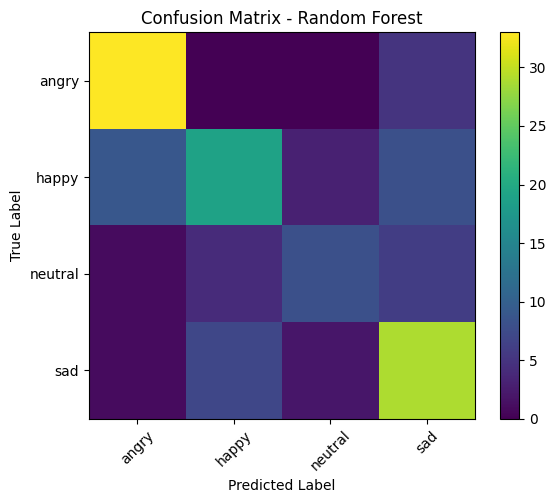


Evaluation for: SVM
Accuracy: 0.6814814814814815

Classification Report:
              precision    recall  f1-score   support

       angry       0.80      0.87      0.84        38
       happy       0.66      0.54      0.59        39
     neutral       0.67      0.42      0.52        19
         sad       0.60      0.77      0.67        39

    accuracy                           0.68       135
   macro avg       0.68      0.65      0.65       135
weighted avg       0.68      0.68      0.67       135

Confusion Matrix:
[[33  1  0  4]
 [ 7 21  2  9]
 [ 0  4  8  7]
 [ 1  6  2 30]]

Confusion Matrix DataFrame:
         angry  happy  neutral  sad
angry       33      1        0    4
happy        7     21        2    9
neutral      0      4        8    7
sad          1      6        2   30


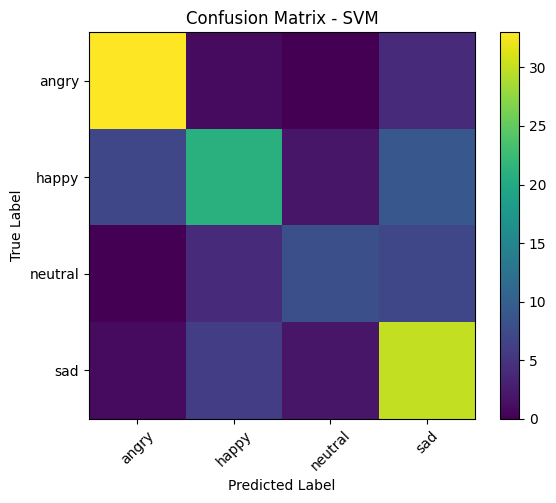


Evaluation for: Logistic Regression
Accuracy: 0.7037037037037037

Classification Report:
              precision    recall  f1-score   support

       angry       0.79      0.87      0.82        38
       happy       0.69      0.56      0.62        39
     neutral       0.58      0.58      0.58        19
         sad       0.69      0.74      0.72        39

    accuracy                           0.70       135
   macro avg       0.69      0.69      0.68       135
weighted avg       0.70      0.70      0.70       135

Confusion Matrix:
[[33  3  0  2]
 [ 6 22  3  8]
 [ 2  3 11  3]
 [ 1  4  5 29]]

Confusion Matrix DataFrame:
         angry  happy  neutral  sad
angry       33      3        0    2
happy        6     22        3    8
neutral      2      3       11    3
sad          1      4        5   29


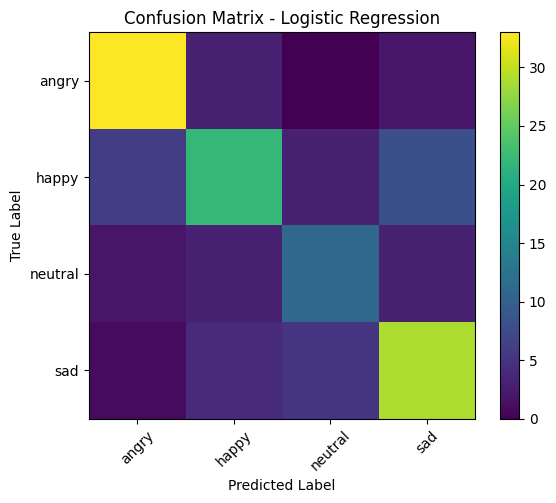


Summary of Results
                 Model  Accuracy
0        Random Forest  0.659259
1                  SVM  0.681481
2  Logistic Regression  0.703704


In [ ]:
# Evaluation of all trained models

results = []

for name, y_pred in predictions.items():
    print("\n" + "=" * 60)
    print(f"Evaluation for: {name}")

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])
    print("Accuracy:", acc)

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    # Get class labels
    model = trained_models[name]
    if hasattr(model, "classes_"):
        class_labels = model.classes_
    else:
        class_labels = model.named_steps[list(model.named_steps.keys())[-1]].classes_

    cm_df = pd.DataFrame(cm, index=class_labels, columns=class_labels)
    print("\nConfusion Matrix DataFrame:")
    print(cm_df)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {name}")
    plt.colorbar()

    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels, rotation=45)
    plt.yticks(tick_marks, class_labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

# Summary table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\n" + "=" * 60)
print("Summary of Results")
print(results_df)

The accuracy score shows the overall performance of each model on the test data.
The classification report provides precision, recall, and F1-score for each emotion class.
The confusion matrix shows how often each emotion was correctly classified and where the model made mistakes.

These results help us understand which emotions are easier to classify and which emotions may overlap in speech patterns, even when using Mel Spectrogram-based features.


# Conclusion
In this notebook, I explored how speech audio can be used for emotion classification.
I extracted **Mel Spectrogram** features from the RAVDESS dataset and trained multiple machine learning models to predict emotions from speech.

The results suggest that speech contains time-frequency patterns related to emotional expression, although some emotions may still be harder to separate than others.
Overall, this project helped me understand the basic workflow of audio processing, feature extraction, and model building in Google Colab.
In the future, the model could be improved by using more advanced features, deep learning models, or larger audio datasets.
